In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

Esto es con 18 MeV lol

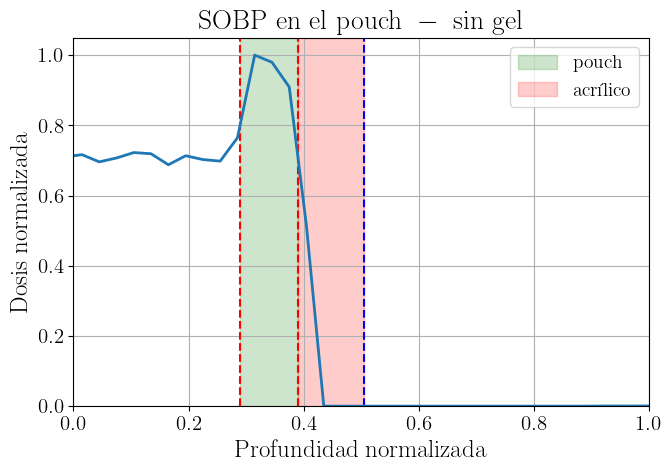

In [15]:

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14
})

archivo = "bragg_pouch_zcilindJesus.out"

z = []
dose = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()

        if len(parts) != 4:
            continue

        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
        except ValueError:
            continue

        z.append((z1 + z2) / 2)
        dose.append(d)

z = np.array(z)
dose = np.array(dose)

orden = np.argsort(z)
z = z[orden]
dose = dose[orden]

n = 3
cantidad = len(z) // n

z_rebin = np.array([
    np.mean(z[i * n:(i + 1) * n])
    for i in range(cantidad)
])

dose_rebin = np.array([
    np.mean(dose[i * n:(i + 1) * n])
    for i in range(cantidad)
])

z_min = 60
z_max = 62
z_rebin_norm = (z_rebin - z_min) / (z_max - z_min)

dose_max = np.max(dose_rebin)
dose_rebin_norm = dose_rebin / dose_max

x1 = (60.58 - z_min) / (z_max - z_min)
x2 = (60.78 - z_min) / (z_max - z_min)
x3 = (61.01 - z_min) / (z_max - z_min)

plt.figure(figsize=(7, 5))

plt.axvline(x=x1, color="r", linestyle="--")
plt.axvline(x=x2, color="r", linestyle="--")
plt.axvline(x=x3, color="b", linestyle="--")

plt.axvspan(x1, x2, color="g", alpha=0.2, label=r"$\mathrm{pouch}$")
plt.axvspan(x2, x3, color="r", alpha=0.2, label=r"$\mathrm{acr\acute{\i}lico}$")

plt.plot(z_rebin_norm, dose_rebin_norm, linewidth=2)

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.xlabel(r"$\mathrm{Profundidad\ normalizada}$")
plt.ylabel(r"$\mathrm{Dosis\ normalizada}$")
plt.title(r"$\mathrm{SOBP\ en\ el\ pouch\ -\ sin\ gel}$")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()